In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pydantic import BaseModel, Field, ValidationError
from typing import Optional
from sklearn.model_selection import StratifiedKFold

# Настраиваем визуализацию
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Pydantic-схема для жесткой фильтрации аномалий
class NomenclatureItem(BaseModel):
    raw_text: str = Field(..., min_length=5, description="Сырое наименование от закупщика")
    target_category: str = Field(..., min_length=2, description="Эталонная категория")

    # Валидатор для отсечения технического мусора из 1С
    @classmethod
    def validate_category(cls, v):
        if "ВЫБЕРИТЕ КОРРЕКТНУЮ ЦН" in v:
            raise ValueError("Технический маркер нераспределенной позиции")
        return v

In [3]:
file_path = "Выгрузка НП-ЦН 100К.csv"

# Читаем файл с указанием кириллической кодировки
df_raw = pd.read_csv(file_path, sep=';', encoding='cp1251', on_bad_lines='skip')
df_raw.columns = ['raw_text', 'target_category']
df_raw = df_raw.dropna()

valid_data = []
errors = {'short_text': 0, 'invalid_category': 0}

# Прогоняем массив через Pydantic
for idx, row in df_raw.iterrows():
    try:
        # Ручная проверка маркера категории перед инициализацией
        if "ВЫБЕРИТЕ КОРРЕКТНУЮ ЦН" in str(row['target_category']):
            errors['invalid_category'] += 1
            continue

        item = NomenclatureItem(
            raw_text=str(row['raw_text']).strip(),
            target_category=str(row['target_category']).strip()
        )
        valid_data.append(item.model_dump())
    except ValidationError:
        errors['short_text'] += 1

df_clean = pd.DataFrame(valid_data)

print(f"Исходных строк: {len(df_raw)}")
print(f"Валидных строк после очистки: {len(df_clean)}")
print(f"Отбраковано мусора (Pydantic): {sum(errors.values())} шт.")

Исходных строк: 102749
Валидных строк после очистки: 101319
Отбраковано мусора (Pydantic): 1430 шт.


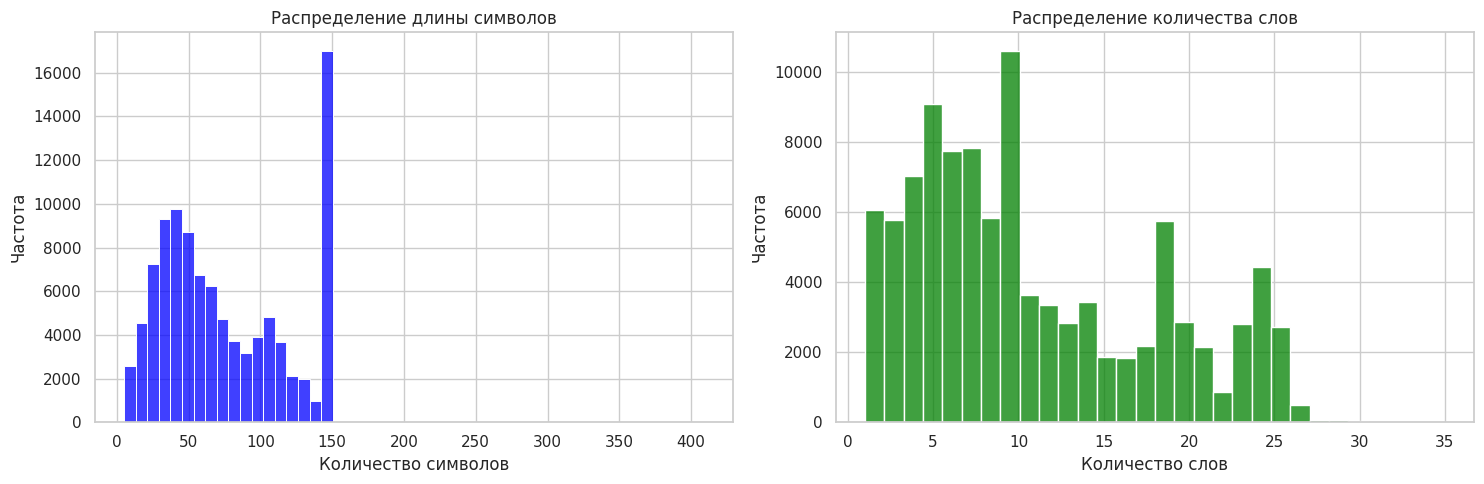


Статистика для параметра max_length токенизатора:
count    101319.000000
mean         10.778413
std           6.941673
min           1.000000
50%           9.000000
75%          16.000000
90%          23.000000
95%          24.000000
99%          25.000000
max          35.000000
Name: word_count, dtype: float64


In [4]:
# Анализ длины строк для настройки RuBERT-tiny2
df_clean['char_length'] = df_clean['raw_text'].apply(len)
df_clean['word_count'] = df_clean['raw_text'].apply(lambda x: len(x.split()))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.histplot(df_clean['char_length'], bins=50, ax=axes[0], color='blue')
axes[0].set_title('Распределение длины символов')
axes[0].set_xlabel('Количество символов')
axes[0].set_ylabel('Частота')

sns.histplot(df_clean['word_count'], bins=30, ax=axes[1], color='green')
axes[1].set_title('Распределение количества слов')
axes[1].set_xlabel('Количество слов')
axes[1].set_ylabel('Частота')

plt.tight_layout()
plt.show()

print("\nСтатистика для параметра max_length токенизатора:")
print(df_clean['word_count'].describe(percentiles=[0.75, 0.90, 0.95, 0.99]))

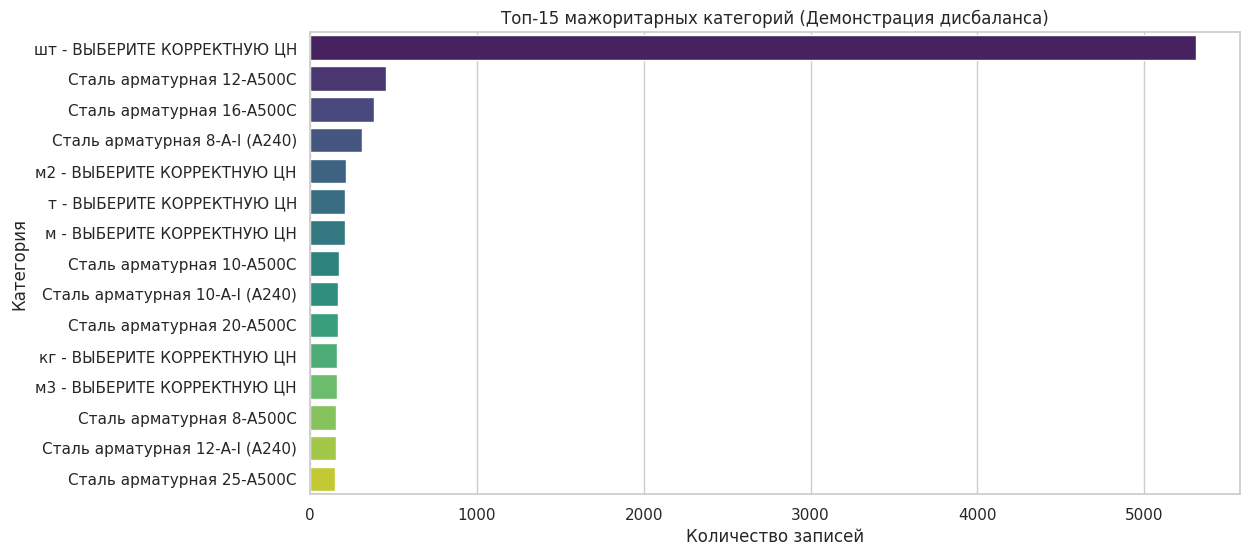

Всего уникальных категорий: 71933
Категорий с менее чем 10 записями: 71652

Данные разбиты на 5 фолдов.
Распределение по фолдам:
fold
0    3780
1    3779
2    3779
4    3779
3    3779
Name: count, dtype: int64


In [6]:
# Анализ "длинного хвоста" классов
top_n = 15
class_counts = df_clean['target_category'].value_counts()

plt.figure(figsize=(12, 6))
sns.barplot(x=class_counts.values[:top_n], y=class_counts.index[:top_n], hue=class_counts.index[:top_n], palette="viridis", legend=False)
plt.title('Топ-15 мажоритарных категорий (Демонстрация дисбаланса)')
plt.xlabel('Количество записей')
plt.ylabel('Категория')
plt.show()

print(f"Всего уникальных категорий: {len(class_counts)}")
print(f"Категорий с менее чем 10 записями: {len(class_counts[class_counts < 10])}")

# Стратифицированная кросс-валидация для редких классов
# Отфильтруем классы, где меньше 5 примеров, чтобы StratifiedKFold отработал корректно
valid_classes = class_counts[class_counts >= 5].index
df_cv = df_clean[df_clean['target_category'].isin(valid_classes)].copy()

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
df_cv['fold'] = -1

for fold_idx, (train_idx, val_idx) in enumerate(skf.split(df_cv['raw_text'], df_cv['target_category'])):
    df_cv.iloc[val_idx, df_cv.columns.get_loc('fold')] = fold_idx

print(f"\nДанные разбиты на {skf.n_splits} фолдов.")
print("Распределение по фолдам:")
print(df_cv['fold'].value_counts())